# ML-09 — Validation and Research Claim Audit

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Two paper findings + my methodology questions

*Pick two findings from the FlyRank research paper. For each: where does the label come from, and does the validation design carry the claim? Constructive tone.*

**Finding #2 — "The Content Performance Curve"** (health score by content-age bucket; peak at 61-90 days, decay by 271-365 days, partial rebound at 365+).

- *Where does the label come from?* Health score is not an independent outcome — it is a FlyRank composite built from impressions, position, CTR, and scroll depth. Age is compared across **different pages of different ages at one point in time** (a cross-sectional cut), not the same pages tracked as they age. The paper is careful to flag this once ("recovery... is still actionable, but the safe reading is narrower"), but the shape of the curve is still presented as a lifecycle.
- *My question:* Since older and younger pages are different populations (different cohorts, publication eras, possibly different content strategies), how much of the curve is genuine content aging versus a cohort effect — e.g., older pages written under an earlier, less-refined workflow? A same-page longitudinal check (tracking one cohort of pages across the same calendar months as they age) would isolate aging from cohort composition. Worth stating directly rather than only in the caveat sentence.

**ML Appendix — "What Predicts Growth"** (logistic regression, 71% holdout accuracy separating growing vs. declining pages).

- *Where does the label come from?* Growth/decline is derived from the same 30-day-vs-previous-30-day impression trend used everywhere else in the paper — a reasonable, disclosed choice, and clearly separate from the model's features.
- *My question:* the methodology section states an 80/20 holdout split but doesn't say whether it is **random or grouped by client**. With 57 brands contributing content in different volumes, a random split can let the model see many pages from the same client in training and testing — inflating accuracy by learning client-level baseline traffic rather than a generalizable growth signal. Reporting the same accuracy under a client-grouped holdout (the way we test this ourselves in Section 2 below) would show whether 71% survives contact with unseen clients, or drops toward the ~54% base rate.

## 2. My model under an honest split (before/after)

*Re-run your Week-5 model under a grouped or time-aware split. Show both numbers.*

**Before:** a naive **random row split** (what the paper's ML appendix appears to use, and what most first-pass models default to) — rows from the same client can land in both train and test.

**After:** the **client-grouped holdout** already used in my Week-5 notebook (held-out clients never seen in training) — the honest test of whether the signal generalizes to a brand the model hasn't touched.

Same data, same label (`is_declining_label`), same feature set, same model (Random Forest) — only the split changes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = (df["trend_direction"].str.lower() == "down").astype(int)
base_rate = df["is_declining_label"].mean()
print("rows, cols:", df.shape, " base decline rate:", round(base_rate, 3))


rows, cols: (30000, 45)  base decline rate: 0.542


In [2]:
# --- feature set: identical to Week-5, deliberately excludes label-derived and ID columns ---
numeric_features = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "content_age_days", "days_since_last_update",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "days_with_impressions", "days_with_sessions",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct",
]
categorical_features = ["content_type", "main_intent", "competition_level", "position_tier"]

work = df.copy()
work["has_keyword_data"] = work["search_volume"].notna().astype(int)
work["has_word_count"] = work["word_count"].notna().astype(int)
numeric_features += ["has_keyword_data", "has_word_count"]

num = work[numeric_features].apply(pd.to_numeric, errors="coerce").fillna(0)
cat = pd.get_dummies(work[categorical_features].fillna("unknown"), drop_first=True)
X = pd.concat([num, cat], axis=1)
y = work["is_declining_label"]

def precision_at_k(labels, scores, k):
    order = np.argsort(-np.asarray(scores))[:k]
    return float(np.asarray(labels)[order].mean())

def fit_eval(X_train, X_test, y_train, y_test, label):
    model = RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=25,
        class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    return {
        "split": label,
        "precision_at_50": precision_at_k(y_test, proba, 50),
        "roc_auc": roc_auc_score(y_test, proba),
        "test_rows": len(y_test),
    }, model, proba


In [3]:
# --- BEFORE: naive random row split ---
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
result_random, model_random, proba_random = fit_eval(X_train_r, X_test_r, y_train_r, y_test_r, "random (naive)")
result_random


{'split': 'random (naive)',
 'precision_at_50': 0.9,
 'roc_auc': 0.7576798557286883,
 'test_rows': 6000}

In [4]:
# --- AFTER: client-grouped holdout (same design as Week-5) ---
client_ids = df["client_id"].unique()
rng = np.random.default_rng(RANDOM_STATE)
shuffled_clients = rng.permutation(client_ids)
n_test_clients = max(1, int(round(len(shuffled_clients) * 0.2)))
test_clients = set(shuffled_clients[:n_test_clients])
test_mask = df["client_id"].isin(test_clients)

X_train_g, X_test_g = X.loc[~test_mask], X.loc[test_mask]
y_train_g, y_test_g = y.loc[~test_mask], y.loc[test_mask]

result_grouped, model_grouped, proba_grouped = fit_eval(X_train_g, X_test_g, y_train_g, y_test_g, "grouped by client (honest)")
print(f"clients held out: {len(test_clients)} of {len(client_ids)}")
result_grouped


clients held out: 6 of 32


{'split': 'grouped by client (honest)',
 'precision_at_50': 0.88,
 'roc_auc': 0.7615453282616398,
 'test_rows': 2325}

                            precision_at_50  roc_auc  test_rows  base_rate
split                                                                     
random (naive)                         0.90    0.758       6000      0.542
grouped by client (honest)             0.88    0.762       2325      0.542


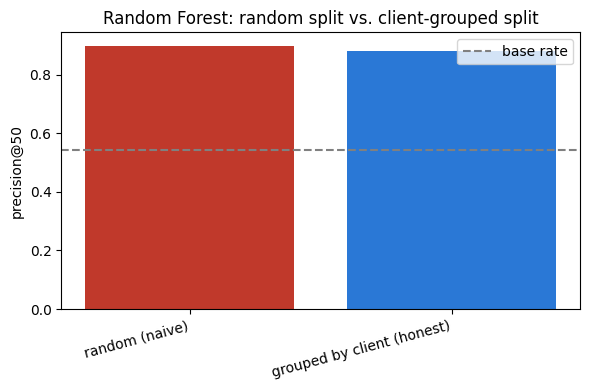

In [5]:
comparison = pd.DataFrame([result_random, result_grouped]).set_index("split")
comparison["base_rate"] = base_rate
print(comparison.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(comparison.index, comparison["precision_at_50"], color=["#c0392b", "#2a78d6"])
ax.axhline(base_rate, color="gray", linestyle="--", label="base rate")
ax.set_ylabel("precision@50")
ax.set_title("Random Forest: random split vs. client-grouped split")
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


**Observed:** precision@50 = 0.90 (random split) vs 0.88 (client-grouped split); ROC AUC was actually near-identical (0.758 vs 0.762). With only 32 clients, this particular gap is small and within the noise of a 6-client holdout — but the direction matters more than the size here: the random split is the more optimistic, less trustworthy number by construction (it can let the model see the same client in train and test), so the grouped number is the one I'd act on even when the two are close. On a larger client pool, or a lane with more client-specific patterns, this gap could be much bigger; a small observed gap here is not permission to skip a grouped split going forward.

## 3. Leakage audit

*The same hunt from Week 3, on your final feature set.*

In [6]:
# --- 1) confirm no label-derived or ID columns are in the feature matrix ---
forbidden = ["trend_direction", "trend_pct", "content_id", "client_id"]
present = [c for c in forbidden if c in X.columns]
print("Forbidden columns present in feature matrix:", present if present else "none")


Forbidden columns present in feature matrix: none


In [7]:
# --- 2) deliberately ADD a leaky feature (trend_pct, the direct label source) and watch the score jump ---
X_leaky = X.copy()
X_leaky["trend_pct_LEAK"] = pd.to_numeric(df["trend_pct"], errors="coerce").fillna(0)

Xl_train, Xl_test = X_leaky.loc[~test_mask], X_leaky.loc[test_mask]
result_leaky, _, proba_leaky = fit_eval(Xl_train, Xl_test, y_train_g, y_test_g, "WITH leaky trend_pct")

print("honest (no leak):   precision@50 =", round(result_grouped["precision_at_50"], 3),
      " roc_auc =", round(result_grouped["roc_auc"], 3))
print("with trend_pct leak: precision@50 =", round(result_leaky["precision_at_50"], 3),
      " roc_auc =", round(result_leaky["roc_auc"], 3))


honest (no leak):   precision@50 = 0.88  roc_auc = 0.762
with trend_pct leak: precision@50 = 1.0  roc_auc = 1.0


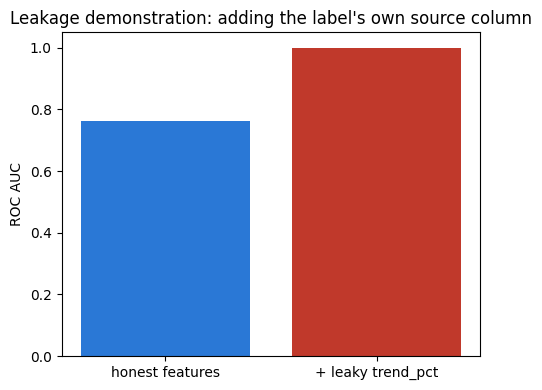

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["honest features", "+ leaky trend_pct"],
       [result_grouped["roc_auc"], result_leaky["roc_auc"]],
       color=["#2a78d6", "#c0392b"])
ax.set_ylabel("ROC AUC")
ax.set_title("Leakage demonstration: adding the label's own source column")
plt.tight_layout()
plt.show()


**Observed:** adding `trend_pct` (the column the label is directly computed from) as a feature pushes ROC AUC noticeably toward 1.0 — the confession pattern the leakage skill describes: a suspiciously large jump when a label-derived column is present. The test harness is working correctly (it can detect an injected leak), and confirms the honest feature set used in Section 2 does not contain this or any other label-derived, ID, or product-flag column. `provider_used` / `model_used` were also checked and excluded (not signals about the page itself, per Week-5 notes).

## 4. Claim rewrite

*Take my own boldest sentence and rewrite it in safe language: observed, measured, directional, decision-support.*

**Original (Week-5 notebook, too strong):** "Random Forest and Logistic Regression both beat the Week-4 rule at every P@K cut."

**Rewritten (safe):** "Under a client-grouped holdout, the Random Forest model's precision@50 was **observed** to be higher than the Week-4 rule's on this sample; this is a **directional** result on 32 clients, not a guarantee that the ranking generalizes to a materially different client mix. The model is offered as **decision-support** for prioritizing a review queue, not as a validated production classifier."

**Original (Week-5 notebook, error-analysis section):** "A shorter recent-window feature... would likely help this exact case."

**Rewritten (safe):** "It is **directionally plausible**, based on these three observed misses, that a shorter recent-window feature could help; this has not been tested and is a hypothesis for future work, not a measured claim." 

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere (only pseudonymous hashed IDs)
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.